# Guía de Trabajo Práctico 5

**Materia**: Aprendizaje Profundo Basado en la Física (optativa del Instituto Balseiro)  
**Docente**: José I. Robledo  
**Edición**: abril-mayo 2026

## Modelos generativos: VAE, NF, GAN y difusión

Dependiendo del conjunto de datos, estos modelos ya se pueden volver demandantes en los recursos computacionales. Recomiendo utilizar las GPUs de Google Colab para el entrenamiento.

---
## Ejercicio 1 — VAE sobre `CelebA`

Vamos a usar un **Variational Autoencoder** sobre una versión reducida de `CelebA`. Para que el entrenamiento sea razonable dentro de una notebook, trabajaremos con imágenes en escala de grises de `56 x 56`.

1. Cargar un subconjunto con `load_celeba_subset(...)`. El conjunto es grande, puede utilizar un conjunto reducido de 50000 datos si desea acelerar el aprendizaje.
2. Inspeccionar algunas caras reales y comentar qué variaciones dominan en el dataset.
3. Plantear un VAE que tome de entrada `image_shape=(1, 56, 56)`.
4. Entrenar el modelo usando ELBO. (opcional: agregar un schedule para el peso de la divergencia KL, para que comience como AE y termine como VAE).
5. Mostrar reconstrucciones del conjunto de prueba.
6. Muestrear del espacio latente y visualizar caras nuevas.
7. Explorar que hiperparámetros cambiaría para mejorar la calidad de la generación

In [ ]:
#!pip -q install kagglehub
import random
from pathlib import Path

import kagglehub


def load_celeba_subset(n_samples=50_000, seed=42):
    """Download CelebA (if needed) and return a deterministic subset of image paths."""
    dataset_path = Path(kagglehub.dataset_download("jessicali9530/celeba-dataset"))

    image_root_candidates = [
        dataset_path / "img_align_celeba" / "img_align_celeba",
        dataset_path / "img_align_celeba",
    ]
    image_root = next((p for p in image_root_candidates if p.exists()), None)
    if image_root is None:
LATENT_DIM = 64
class GeneratorCNN(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super(GeneratorCNN, self).__init__()
        self.latent_dim = latent_dim
        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 256 * 6 * 6),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (256, 6, 6)),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),  # 6 -> 12
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=0),  # 12 -> 25
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        h_dec = self.decoder_input(z)
        recon_x = self.decoder(h_dec)
        return recon_x

class DiscriminatorCNN(nn.Module):
    def __init__(self):
        super(DiscriminatorCNN, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 25 -> 13
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 13 -> 7
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.encoder(x)

generator = GeneratorCNN(latent_dim=LATENT_DIM)
discriminator = DiscriminatorCNN()
print(generator)
print(discriminator)

torch.manual_seed(SEED)

Dataset root: C:\Users\migue\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2\img_align_celeba\img_align_celeba
Subset size: 50000
Ejemplo: C:\Users\migue\.cache\kagglehub\datasets\jessicali9530\celeba-dataset\versions\2\img_align_celeba\img_align_celeba\000003.jpg


In [16]:
class CelebAFilesDataset(torch.utils.data.Dataset):
    def __init__(self, file_paths, transform=None):
        self.file_paths = list(file_paths)
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img = Image.open(self.file_paths[idx]).convert("L")
        if self.transform is not None:
            img = self.transform(img)
        return img


transform = transforms.Compose(
    [
        transforms.Resize((56, 56)),
        transforms.ToTensor(),
    ]
)

all_dataset = CelebAFilesDataset(subset_files, transform=transform)

n_train = int(0.7 * len(all_dataset))
n_val = len(all_dataset) - n_train
train_dataset, val_dataset = torch.utils.data.random_split(
    all_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Sample shape: {all_dataset[0].shape}")


Train size: 35000
Val size: 15000
Sample shape: torch.Size([1, 56, 56])


In [17]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Train batches: 274
Val batches: 118


In [18]:
class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # 56 -> 28
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 28 -> 14
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 14 -> 7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Linear(256, 2 * latent_dim),
        )

        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128 * 7 * 7),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 14 -> 28
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # 28 -> 56
            nn.Sigmoid(),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, logvar = h[:, : self.latent_dim], h[:, self.latent_dim :]
        z = self.reparameterize(mu, logvar)
        h_dec = self.decoder_input(z)
        recon_x = self.decoder(h_dec)
        return recon_x, mu, logvar

In [ ]:
def train_vae(model, train_loader, val_loader, epochs=10, lr=1e-3, beta_max=1.0, beta_schedule_type="linear"):
    """
    Train a VAE with optional KL annealing schedule.
    
    Args:
        beta_max: Maximum value for KL weight factor
        beta_schedule_type: "linear" (ramp up linearly) or "constant" (use beta_max immediately)
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def get_beta(epoch, total_epochs, beta_max, schedule_type="linear"):
        """Calculate beta factor for current epoch."""
        if schedule_type == "linear":
            return min(beta_max * (epoch / max(total_epochs - 1, 1)), beta_max)
        else:
            return beta_max

    for epoch in range(epochs):
        beta = get_beta(epoch, epochs, beta_max, beta_schedule_type)
        
        model.train()
        train_loss = 0
        for batch in train_loader:
            batch = batch.to(device)
            recon_batch, mu, logvar = model(batch)
            recon_loss = nn.functional.binary_cross_entropy(
                recon_batch, batch, reduction="sum"
            )
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + beta * kl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        avg_rec_loss = recon_loss.item() / len(train_loader.dataset)
        avg_kl_loss = kl_loss.item() / len(train_loader.dataset) 

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                recon_batch, mu, logvar = model(batch)
                recon_loss = nn.functional.binary_cross_entropy(
                    recon_batch, batch, reduction="sum"
                )
                kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + beta * kl_loss
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader.dataset)
        print(f"Epoch {epoch+1}/{epochs} - Beta: {beta:.4f} - Rec Train Loss: {avg_rec_loss:.4f} - KL Train Loss: {avg_kl_loss:.4f} - Val Loss: {avg_val_loss:.4f}")


In [ ]:
# Entrenar el modelo con KL annealing schedule
vae_model = VAE(latent_dim=20)
train_vae(vae_model, train_loader, val_loader, epochs=10, lr=1e-3, beta_max=0.3, beta_schedule_type="linear")


Epoch 1/10 - Beta: 0.0000 - Train Loss: 1825.2680 - Val Loss: 1726.3842
Epoch 2/10 - Beta: 0.1111 - Train Loss: 1707.9703 - Val Loss: 1695.1432
Epoch 3/10 - Beta: 0.2222 - Train Loss: 1695.6529 - Val Loss: 1692.6007
Epoch 4/10 - Beta: 0.3333 - Train Loss: 1694.6040 - Val Loss: 1693.2073
Epoch 5/10 - Beta: 0.4444 - Train Loss: 1695.6375 - Val Loss: 1697.3141


KeyboardInterrupt: 

In [26]:
train_vae(vae_model, train_loader, val_loader, epochs=10, lr=1e-3, beta_max=0.3, beta_schedule_type="linear")

Epoch 1/10 - Beta: 0.0000 - Train Loss: 1675.1447 - Val Loss: 1672.6800
Epoch 2/10 - Beta: 0.0333 - Train Loss: 1670.7775 - Val Loss: 1678.5881
Epoch 3/10 - Beta: 0.0667 - Train Loss: 1671.8551 - Val Loss: 1674.4805


KeyboardInterrupt: 

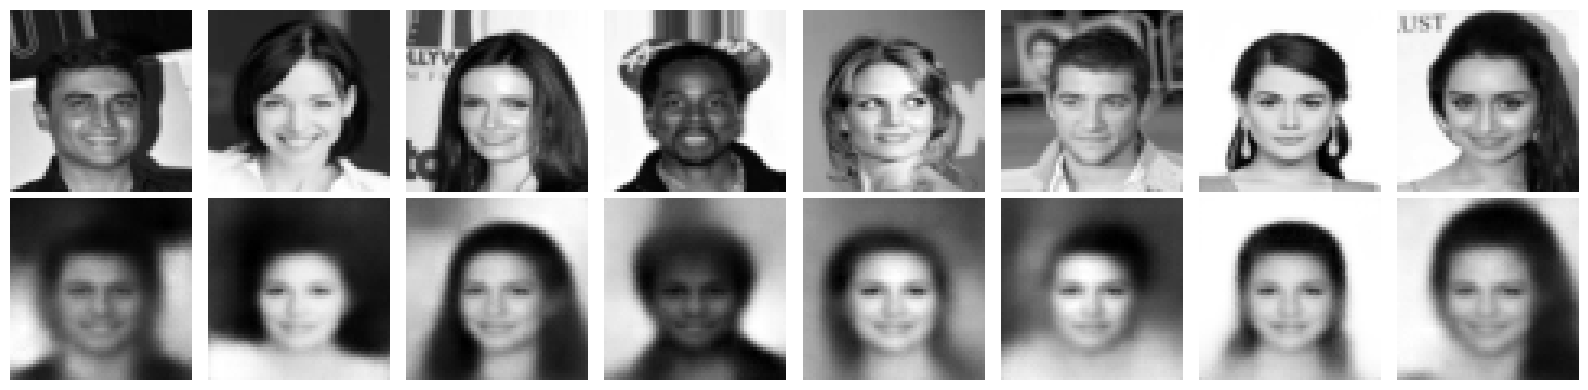

In [27]:
# Mostrar Reconstrucciones de Prueba
def show_reconstructions(model, data_loader, n_images=8):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    with torch.no_grad():
        batch = next(iter(data_loader))
        batch = batch.to(device)
        recon_batch, _, _ = model(batch)
        recon_batch = recon_batch.cpu()
        fig, axes = plt.subplots(2, n_images, figsize=(n_images * 2, 4))
        for i in range(n_images):
            axes[0, i].imshow(batch[i].cpu().squeeze(), cmap="gray")
            axes[0, i].axis("off")
            axes[1, i].imshow(recon_batch[i].squeeze(), cmap="gray")
            axes[1, i].axis("off")
        plt.tight_layout()
        plt.show()

show_reconstructions(vae_model, val_loader, n_images=8)

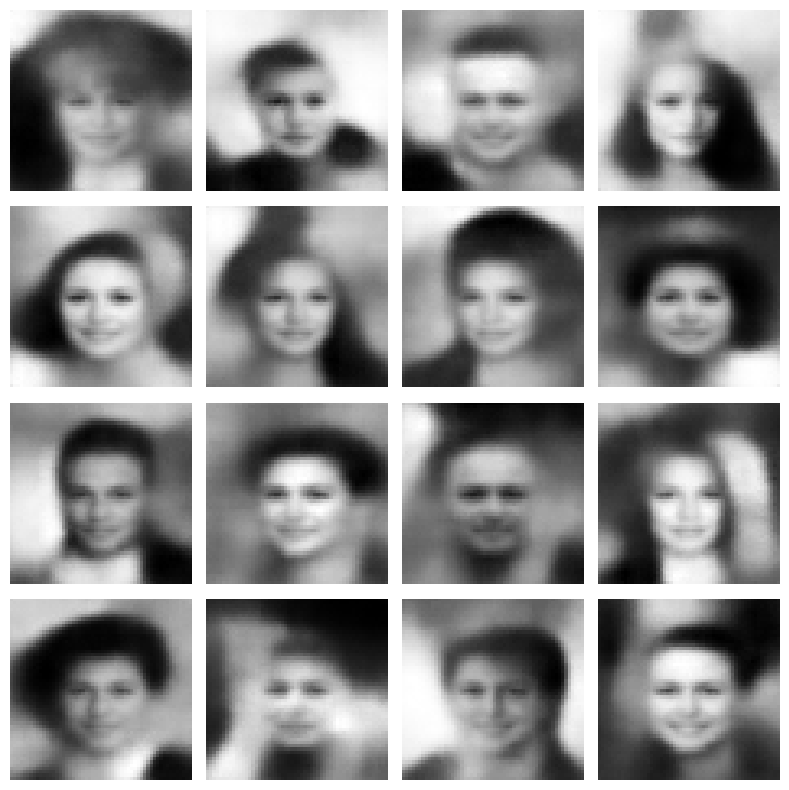

In [59]:
# Muestrear el espacio latente
def sample_latent_space(model, n_samples=16):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, model.latent_dim).to(device)
        h_dec = model.decoder_input(z)
        recon_x = model.decoder(h_dec)
        recon_x = recon_x.cpu()
        n_cols = int(math.sqrt(n_samples))
        fig, axes = plt.subplots(n_cols, n_cols, figsize=(n_cols * 2, n_cols * 2))
        for i in range(n_samples):
            ax = axes[i // n_cols, i % n_cols]
            ax.imshow(recon_x[i].squeeze(), cmap="gray")
            ax.axis("off")
        plt.tight_layout()
        plt.show()

sample_latent_space(vae_model, n_samples=16)

---
## Ejercicio 2 — Normalizing Flow con `zuko` y `MAF`

En este ejercicio vas a ajustar un **Masked Autoregressive Flow (MAF)** usando `zuko` sobre un patrón bidimensional de dos medias lunas. El objetivo es que la idea de modelar densidades exactas se vea de forma geométrica y con una implementación compacta.

1. Generar un dataset 2D cuya densidad de probabilidad conste de tres densidades gaussianas centradas en distintos valores medios y con distintos anchos. Puede modificar la densidad de probabilidad para simplificar/complicar la distribución objetivo si lo desea.
2. Graficar la nube real para inspeccionar su forma.
3. Instanciar un flow con `zuko.flows.MAF(features=2, ...)`.
4. Entrenarlo por máxima verosimilitud, minimizandoel negativo de la log verosimilitud `-flow().log_prob(x)`.
5. Muestrear del modelo entrenado con `flow().sample((n,))` y comparar nube real vs nube generada.
6. Repetir el ejercicio con un RealNVP y comparar resultado respecto a MAF.

---
## Ejercicio 3 — GAN sobre configuraciones del modelo de Ising 2D

Ahora trabajaremos con `ising_dataset.pt`, que contiene configuraciones del modelo de Ising ya simuladas. Cada muestra puede verse como una imagen binaria con espines `-1/+1`, según el preprocesado.

1. Cargar el subconjunto de ising_dataset.pt utilizado anteriormente. Preprocesarlo para seleccionar solo las imagenes por encima de la T_c. 
2. Inspeccionar varias configuraciones reales y discutir qué estructura espacial aparece.
3. Entrenar una GAN de las vistas en el curso a eleccion.
4. Visualizar muestras generadas y compararlas con las reales.
5. Monitorear `d_loss` y `g_loss` durante el entrenamiento.
6. Repetir el ejercicio pero esta vez utilizando solo las imagenes por debajo de T_c. Las imágenes generadas, se parecen a las utilizadas para entrenar? 
7. (Opcional) repetir el ejercicio de la guía 02, pero con un conjunto de imágenes generadas por encima y por debajo de la T_c, utilizando ambos modelos entrenados. Logramos entrenar un clasificador con estos datos?


Archivo cargado: G:\Mi unidad\2026\APBFpractica\data\ising_dataset.pt
Tipo de objeto: <class 'dict'>
Claves disponibles: ['X_train', 'y_train', 'X_test', 'y_test']
Shape de x: (1000, 625)
Shape de y: (1000,)
Subset por encimaB de Tc: 550 muestras


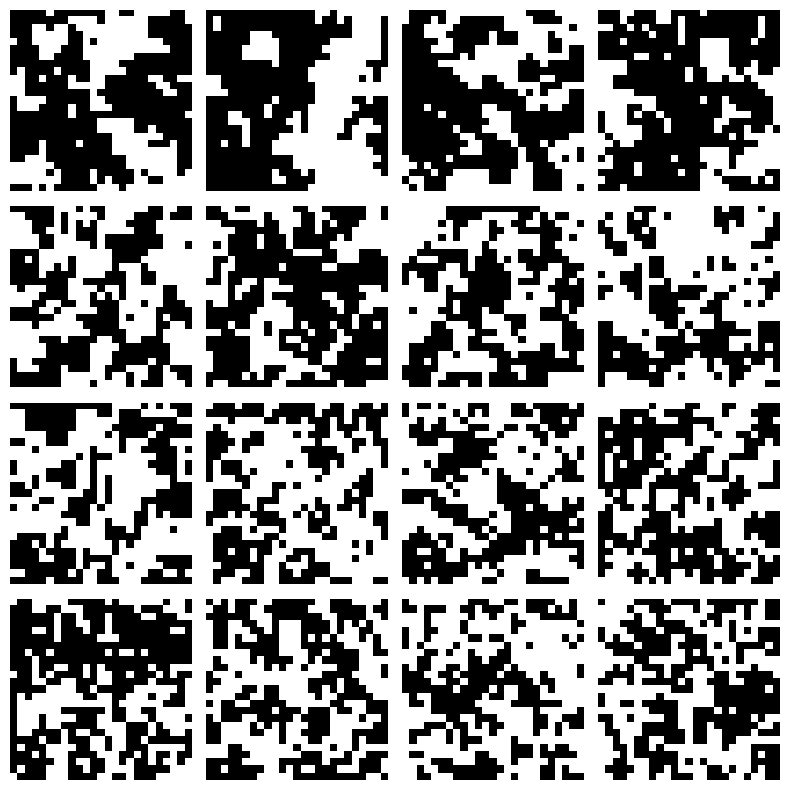

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch


ising_path = Path(r"G:\Mi unidad\2026\APBFpractica\data\ising_dataset.pt")
ising_data = torch.load(ising_path, map_location="cpu")
print(f"Archivo cargado: {ising_path}")
print(f"Tipo de objeto: {type(ising_data)}")

if isinstance(ising_data, dict):
    print(f"Claves disponibles: {list(ising_data.keys())}")

    if {"X_train", "y_train", "X_test", "y_test"}.issubset(ising_data.keys()):
        x = torch.cat([torch.as_tensor(ising_data["X_train"]), torch.as_tensor(ising_data["X_test"])], dim=0)
        y = torch.cat([torch.as_tensor(ising_data["y_train"]), torch.as_tensor(ising_data["y_test"])], dim=0)
    else:
        x = None
        y = None
        for x_key in ["x", "X", "data", "images", "configs", "configurations"]:
            if x_key in ising_data:
                x = ising_data[x_key]
                break
        for y_key in ["y", "Y", "labels", "target", "targets", "temperature_label"]:
            if y_key in ising_data:
                y = ising_data[y_key]
                break

        if x is None or y is None:
            raise KeyError("No se pudieron identificar las claves de datos y etiquetas en el archivo .pt")
else:
    if not isinstance(ising_data, (list, tuple)) or len(ising_data) < 2:
        raise TypeError("Se esperaba un dict o una tupla/lista con datos y etiquetas.")
    x, y = ising_data[0], ising_data[1]

x = torch.as_tensor(x)
y = torch.as_tensor(y).long().view(-1)
print(f"Shape de x: {tuple(x.shape)}")
print(f"Shape de y: {tuple(y.shape)}")

above_tc_mask = (y == 1)
x_above_tc = x[above_tc_mask]
y_above_tc = y[above_tc_mask]
print(f"Subset por encimaB de Tc: {len(x_above_tc)} muestras")

# Visualizar algunas configuraciones reales por encima de Tc
n_preview = min(16, len(x_above_tc))
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
axes = axes.ravel()
for ax, sample in zip(axes, x_above_tc[:n_preview]):
    img = sample.reshape(25, 25).float()
    ax.imshow(img, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

for ax in axes[n_preview:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [3]:
from torch.utils.data import DataLoader
data_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

NameError: name 'train_dataset' is not defined

In [27]:
import torch
from torch import nn

class GeneratorCNN(nn.Module):
    def __init__(self, latent_dim=32):
        super(GeneratorCNN, self).__init__()
        self.latent_dim = latent_dim
        # Base spatial size shifted to 4x4 to cleanly reach 25x25 without padding
        self.decoder_input = nn.Sequential(
            nn.Linear(latent_dim, 32 * 4 * 4),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (32, 4, 4)),
            # Output: (4-1)*2 + 4 = 10
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=0),  
            nn.BatchNorm2d(16),
            nn.ReLU(),
            # Output: (10-1)*2 + 4 = 22
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=0),   
            nn.BatchNorm2d(8),
            nn.ReLU(),
            # Output: (22-1)*1 + 4 = 25
            nn.ConvTranspose2d(8, 1, kernel_size=4, stride=1, padding=0),    
            nn.Tanh(),
        )

    def forward(self, z):
        h_dec = self.decoder_input(z)
        recon_x = self.decoder(h_dec)
        return recon_x
    
class DiscriminatorCNN(nn.Module):
    def __init__(self):
        super(DiscriminatorCNN, self).__init__()
        self.encoder = nn.Sequential(
            # Output: floor((25-4)/2) + 1 = 11
            nn.Conv2d(1, 4, kernel_size=4, stride=2, padding=0),  
            nn.LeakyReLU(0.2),
            # Output: floor((11-4)/2) + 1 = 4
            nn.Conv2d(4, 8, kernel_size=4, stride=2, padding=0),  
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(8 * 4 * 4, 8),
            nn.LeakyReLU(0.2),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.encoder(x)

In [28]:
LATENT_DIM = 10
generator = GeneratorCNN(latent_dim=LATENT_DIM)
discriminator = DiscriminatorCNN()

bce_logits = nn.BCEWithLogitsLoss()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def sample_latent(n_samples, latent_dim=LATENT_DIM, device=DEVICE):
    return torch.randn(n_samples, latent_dim, device=device)


@torch.no_grad()
def generate_samples(generator, n_samples):
    z = sample_latent(n_samples, device=next(generator.parameters()).device)
    return generator(z)


def train_gan(generator, discriminator, data, epochs=800, batch_size=64, lr_g=2e-4, lr_d=1e-4, alpha_d_loss=0.5, label_smoothing=0.1, noise_std_max=0.05, verbose_every=100):
    generator = generator.to(DEVICE)
    discriminator = discriminator.to(DEVICE)
    data = data.to(DEVICE)

    g_optimizer = torch.optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999), weight_decay=1e-5)
    d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999), weight_decay=1e-3)

    history = {"g_loss": [], "d_loss": [], "real_score": [], "fake_score": []}

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(data.size(0), device=data.device)
        total_g = 0.0
        total_d = 0.0
        total_real_score = 0.0
        total_fake_score = 0.0
        n_seen = 0

        noise_scale = noise_std_max * (1.0 - (epoch - 1) / max(epochs - 1, 1))

        for i in range(0, data.size(0), batch_size):
            idx = perm[i : i + batch_size]
            real_batch = data[idx]
            current_batch_size = real_batch.size(0)

            real_targets = torch.empty(current_batch_size, 1, device=data.device).uniform_(1.0 - label_smoothing, 1.0)
            fake_targets = torch.empty(current_batch_size, 1, device=data.device).uniform_(0.0, label_smoothing)

            z = sample_latent(current_batch_size, device=data.device)
            fake_batch = generator(z)

            if noise_scale > 0:
                real_batch_input = real_batch + noise_scale * torch.randn_like(real_batch)
                fake_batch_input = fake_batch.detach() + noise_scale * torch.randn_like(fake_batch)
            else:
                real_batch_input = real_batch
                fake_batch_input = fake_batch.detach()

            real_logits = discriminator(real_batch_input)
            fake_logits = discriminator(fake_batch_input)

            d_loss_real = bce_logits(real_logits, real_targets)
            d_loss_fake = bce_logits(fake_logits, fake_targets)
            d_loss = alpha_d_loss * (d_loss_real + d_loss_fake)

            d_optimizer.zero_grad()
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=5.0)
            d_optimizer.step()

            z = sample_latent(current_batch_size, device=data.device)
            generated_batch = generator(z)
            generated_logits = discriminator(generated_batch)

            g_targets = torch.ones(current_batch_size, 1, device=data.device)
            g_loss = bce_logits(generated_logits, g_targets)

            g_optimizer.zero_grad()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=5.0)
            g_optimizer.step()

            total_d += d_loss.item() * current_batch_size
            total_g += g_loss.item() * current_batch_size
            total_real_score += torch.sigmoid(real_logits).mean().item() * current_batch_size
            total_fake_score += torch.sigmoid(fake_logits).mean().item() * current_batch_size
            n_seen += current_batch_size

        history["d_loss"].append(total_d / n_seen)
        history["g_loss"].append(total_g / n_seen)
        history["real_score"].append(total_real_score / n_seen)
        history["fake_score"].append(total_fake_score / n_seen)

        if epoch % verbose_every == 0 or epoch == 1:
            print(
                f"epoch={epoch:4d}  d_loss={history['d_loss'][-1]:.4f}  "
                f"g_loss={history['g_loss'][-1]:.4f}  "
                f"D(real)={history['real_score'][-1]:.3f}  "
                f"D(fake)={history['fake_score'][-1]:.3f}"
            )

    return history


# Reshape x_above_tc to 4D format: (batch_size, 1, 25, 25)
x_above_tc_reshaped = x_above_tc

# Reshape x_above_tc to 4D format: (batch_size, 1, 25, 25)
x_above_tc_reshaped = x_above_tc.view(-1, 1, 25, 25).float()

history = train_gan(
    generator,
    discriminator,
    x_above_tc_reshaped,
    epochs=800,
    batch_size=64,
    lr_g=2e-4,
    lr_d=1e-4,
    verbose_every=10,
)


epoch=   1  d_loss=0.6981  g_loss=0.6694  D(real)=0.506  D(fake)=0.511
epoch=  10  d_loss=0.7158  g_loss=0.6330  D(real)=0.507  D(fake)=0.531
epoch=  20  d_loss=0.6991  g_loss=0.6629  D(real)=0.509  D(fake)=0.516
epoch=  30  d_loss=0.6980  g_loss=0.6672  D(real)=0.508  D(fake)=0.513
epoch=  40  d_loss=0.6946  g_loss=0.6742  D(real)=0.508  D(fake)=0.510
epoch=  50  d_loss=0.6958  g_loss=0.6752  D(real)=0.506  D(fake)=0.509
epoch=  60  d_loss=0.6945  g_loss=0.6835  D(real)=0.503  D(fake)=0.505
epoch=  70  d_loss=0.6943  g_loss=0.6854  D(real)=0.503  D(fake)=0.504
epoch=  80  d_loss=0.6941  g_loss=0.6854  D(real)=0.503  D(fake)=0.504
epoch=  90  d_loss=0.6941  g_loss=0.6879  D(real)=0.502  D(fake)=0.503
epoch= 100  d_loss=0.6930  g_loss=0.6892  D(real)=0.502  D(fake)=0.502
epoch= 110  d_loss=0.6928  g_loss=0.6878  D(real)=0.503  D(fake)=0.503
epoch= 120  d_loss=0.6933  g_loss=0.6907  D(real)=0.501  D(fake)=0.501
epoch= 130  d_loss=0.6927  g_loss=0.6939  D(real)=0.500  D(fake)=0.500
epoch=

KeyboardInterrupt: 

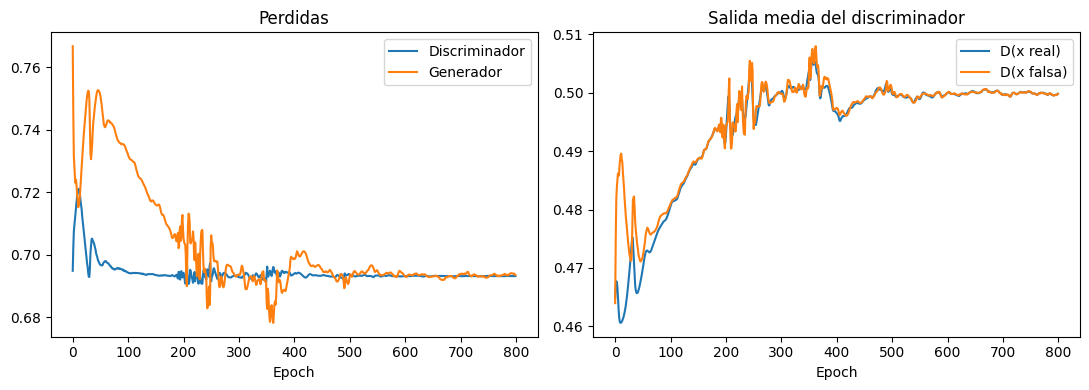

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["d_loss"], label="Discriminador")
axes[0].plot(history["g_loss"], label="Generador")
axes[0].set_title("Perdidas")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["real_score"], label="D(x real)")
axes[1].plot(history["fake_score"], label="D(x falsa)")
axes[1].set_title("Salida media del discriminador")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


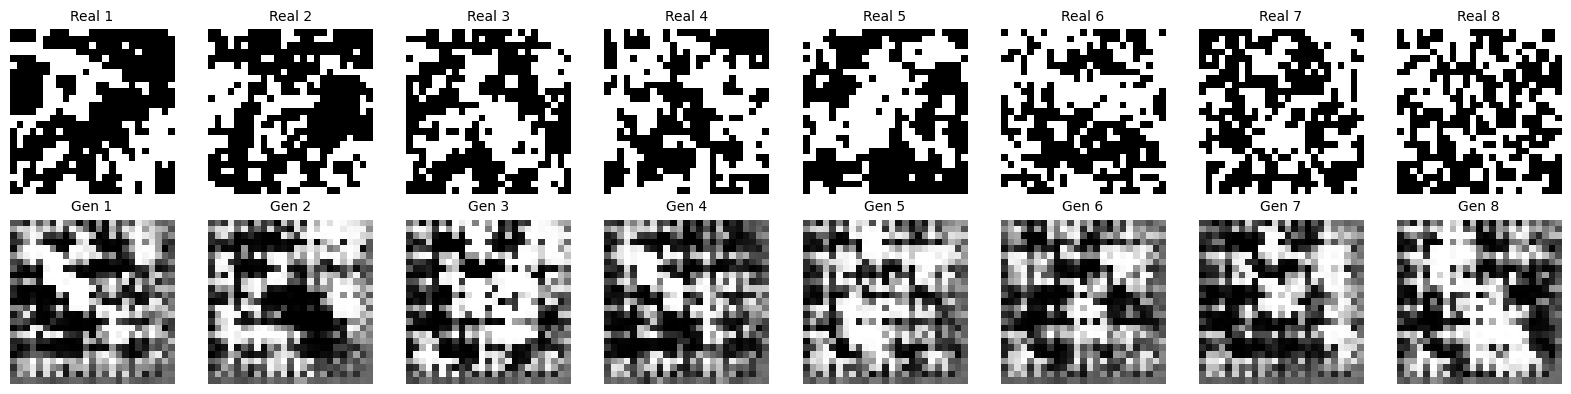

In [26]:
# Visualizar muestras generadas vs reales
@torch.no_grad()
def compare_generated_vs_real(generator, real_data, n_samples=8):
    device = next(generator.parameters()).device
    generator.eval()
    
    # Generar muestras sintéticas
    z = torch.randn(n_samples, LATENT_DIM, device=device)
    generated = generator(z).cpu()
    

    
    # Seleccionar muestras reales aleatorias
    idx = torch.randperm(len(real_data))[:n_samples]
    real_samples = real_data[idx].view(-1, 1, 25, 25).float()
    
    # Crear grilla: 2 filas (real/generada) x n_samples columnas
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 2, 4))
    
    for i in range(n_samples):
        # Fila 0: muestras reales
        axes[0, i].imshow(real_samples[i].squeeze().numpy(), cmap="gray", vmin=-1, vmax=1)
        axes[0, i].set_title(f"Real {i+1}", fontsize=10)
        axes[0, i].axis("off")
        
        # Fila 1: muestras generadas
        axes[1, i].imshow(generated[i].squeeze().numpy(), cmap="gray", vmin=-1, vmax=1)
        axes[1, i].set_title(f"Gen {i+1}", fontsize=10)
        axes[1, i].axis("off")
    
    # Etiquetas de fila
    axes[0, 0].set_ylabel("Real", fontsize=12, fontweight="bold")
    axes[1, 0].set_ylabel("Generada", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.show()

compare_generated_vs_real(generator, x_above_tc, n_samples=8)


---
## Ejercicio 4 — Modelo de difusión sobre señales amortiguadas

Para cerrar, vamos a usar un **DDPM** simple sobre señales 1D. Acá las muestras son vectores cortos, así que un predictor de ruido tipo MLP resulta suficiente para experimentar.

1. Generar un dataset con `make_damped_signal_dataset(...)`.
2. Visualizar algunas señales reales para identificar amplitud, frecuencia y amortiguamiento.
3. Instanciar `DiffusionSchedule` y `NoisePredictor`.
4. Entrenar el modelo con pérdida MSE sobre el ruido predicho.
5. Muestrear señales nuevas con `sample_ddpm(...)` y evaluar la calidad de generación visualmente.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_damped_signal_dataset(n_samples=2048, n_points=96):
    t = torch.linspace(0.0, 2.0, n_points)
    signals = []
    params = []
    for _ in range(n_samples):
        amplitude = 0.7 + 0.5 * torch.rand(1)
        beta = 0.15 + 0.6 * torch.rand(1)
        omega = 3.0 + 4.5 * torch.rand(1)
        phase = 2 * torch.pi * torch.rand(1)
        signal = amplitude * torch.exp(-beta * t) * torch.sin(omega * t + phase)
        signal = signal + 0.03 * torch.randn_like(signal)
        signals.append(signal)
        params.append(torch.cat([amplitude, beta, omega, phase]))
    return t, torch.stack(signals), torch.stack(params)

# Clases auxiliares --
# Dejo estas clases por si las quieren utilizar. Pueden generar las suyas propias si lo desean.
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim, max_period=10000, total_steps=100):
        super().__init__()
        self.dim = dim
        self.max_period = max_period
        self.total_steps = total_steps

    def forward(self, t):
        half_dim = self.dim // 2
        scale = math.log(self.max_period) / max(half_dim - 1, 1)
        freqs = torch.exp(-scale * torch.arange(half_dim, device=t.device, dtype=torch.float32))
        angles = (t.float().unsqueeze(1) / max(self.total_steps - 1, 1)) * freqs.unsqueeze(0) * 1000.0
        emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


class NoisePredictor(nn.Module):
    def __init__(self, data_dim, time_dim=128, hidden_dim=256, total_steps=100):
        super().__init__()
        self.time_embedding = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim, total_steps=total_steps),
            nn.Linear(time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.net = nn.Sequential(
            nn.Linear(data_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, data_dim),
        )

    def forward(self, x, t):
        t_emb = self.time_embedding(t)
        return self.net(torch.cat([x, t_emb], dim=1))
    
@torch.no_grad()
def sample_ddpm(model, schedule, n_samples, data_dim, device=DEVICE):
    model.eval()
    schedule = schedule.to(device)
    x = torch.randn(n_samples, data_dim, device=device)
    snapshots = []
    capture_steps = {schedule.T - 1, schedule.T // 2, schedule.T // 4, 0}

    for step in reversed(range(schedule.T)):
        t = torch.full((n_samples,), step, device=device, dtype=torch.long)
        predicted_noise = model(x, t)
        beta_t = schedule.extract(schedule.betas, t, x.shape)
        sqrt_one_minus_alpha_bar_t = schedule.extract(schedule.sqrt_one_minus_alpha_bars, t, x.shape)
        sqrt_recip_alpha_t = schedule.extract(schedule.sqrt_recip_alphas, t, x.shape)
        mean = sqrt_recip_alpha_t * (x - beta_t * predicted_noise / sqrt_one_minus_alpha_bar_t)
        if step > 0:
            posterior_var_t = schedule.extract(schedule.posterior_variance, t, x.shape).clamp_min(1e-20)
            x = mean + torch.sqrt(posterior_var_t) * torch.randn_like(x)
        else:
            x = mean
        if step in capture_steps:
            snapshots.append((step, x.detach().cpu()))

    return x, snapshots



In [21]:
# Generar dataset de señales amortiguadas
t, signals, params = make_damped_signal_dataset(n_samples=4048, n_points=50)
print(f"Shape de t: {t.shape}")
print(f"Shape de signals: {signals.shape}")
print(f"Shape de params: {params.shape}")

Shape de t: torch.Size([50])
Shape de signals: torch.Size([4048, 50])
Shape de params: torch.Size([4048, 4])


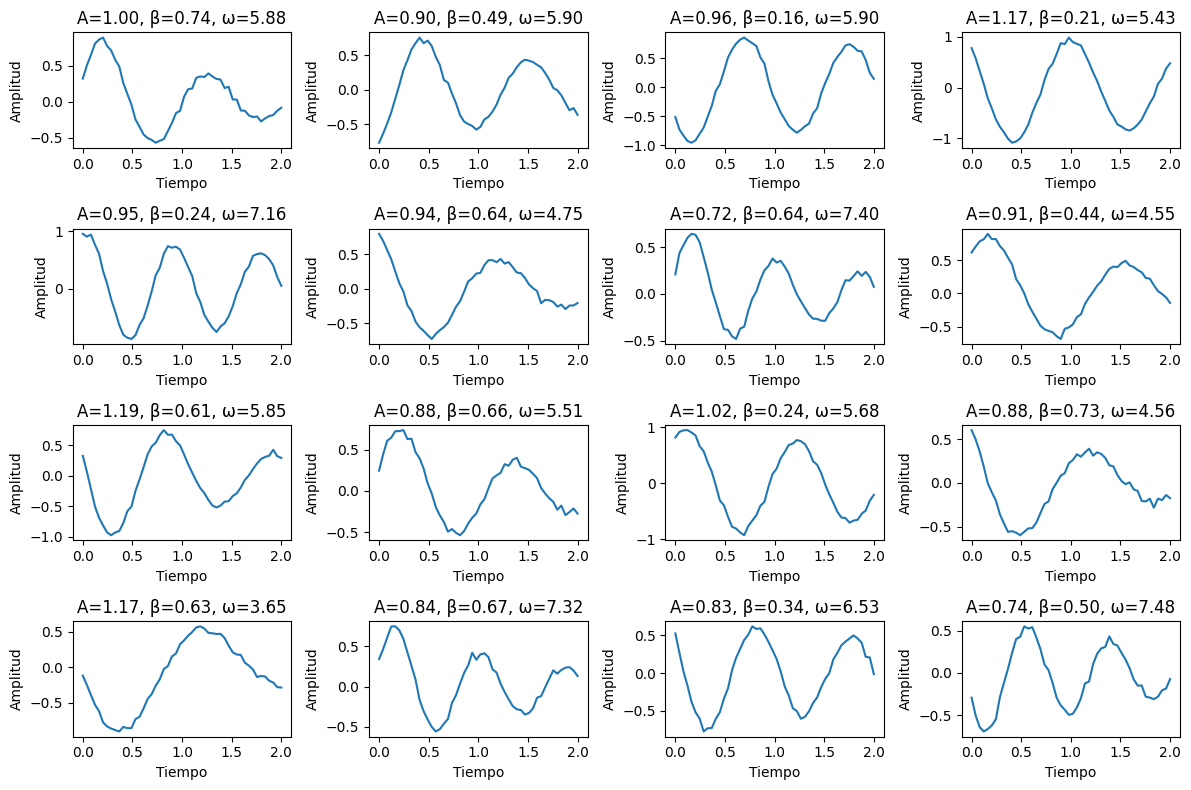

In [22]:
import matplotlib.pyplot as plt
# Visualizar algunas señales de ejemplo
n_preview = 16
fig, axes = plt.subplots(4, 4, figsize=(12, 8))
for i in range(n_preview):
    axes[i // 4, i % 4].plot(t, signals[i])
    axes[i // 4, i % 4].set_title(f"A={params[i,0]:.2f}, β={params[i,1]:.2f}, ω={params[i,2]:.2f}")
    axes[i // 4, i % 4].set_xlabel("Tiempo")
    axes[i // 4, i % 4].set_ylabel("Amplitud")
plt.tight_layout()
plt.show()

In [23]:
class DiffusionSchedule:
    def __init__(self, T=100, beta_start=1e-4, beta_end=2e-2, device=DEVICE):
        self.T = T
        self.device = device
        self.betas = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas = 1.0 - self.betas
        self.sqrt_recip_alphas = torch.rsqrt(self.alphas)
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - self.alpha_bars)
        alpha_bars_prev = F.pad(self.alpha_bars[:-1], (1, 0), value=1.0)
        self.posterior_variance = self.betas * (1.0 - alpha_bars_prev) / (1.0 - self.alpha_bars)

    def extract(self, coefficients, t, x_shape):
        out = coefficients.gather(0, t)
        return out.view(-1, *([1] * (len(x_shape) - 1)))

    def to(self, device):
        self.device = device
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.sqrt_recip_alphas = self.sqrt_recip_alphas.to(device)
        self.alpha_bars = self.alpha_bars.to(device)
        self.sqrt_one_minus_alpha_bars = self.sqrt_one_minus_alpha_bars.to(device)
        self.posterior_variance = self.posterior_variance.to(device)
        return self


# Instanciar DiffusionSchedule y NoisePredictor para señales 1D.
schedule = DiffusionSchedule(T=100)
noise_predictor = NoisePredictor(data_dim=signals.shape[1], total_steps=schedule.T)

# Entrenamiento del modelo de predicción de ruido
def train_diffusion_model(model, schedule, data, epochs=50, batch_size=64, lr=1e-3, verbose_every=5):
    model = model.to(DEVICE)
    data = data.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        perm = torch.randperm(data.size(0), device=data.device)
        total_loss = 0.0
        n_seen = 0

        for i in range(0, data.size(0), batch_size):
            idx = perm[i : i + batch_size]
            real_batch = data[idx]
            current_batch_size = real_batch.size(0)

            t = torch.randint(0, schedule.T, (current_batch_size,), device=data.device)
            noise = torch.randn_like(real_batch)
            noisy_input = schedule.extract(schedule.sqrt_one_minus_alpha_bars, t, real_batch.shape) * noise + schedule.extract(schedule.sqrt_recip_alphas, t, real_batch.shape) * real_batch

            predicted_noise = model(noisy_input, t)
            loss = mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * current_batch_size
            n_seen += current_batch_size

        avg_loss = total_loss / n_seen
        if epoch % verbose_every == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.6f}")

In [24]:
train_diffusion_model(noise_predictor, schedule, signals, epochs=500, batch_size=64, lr=1e-3)

Epoch 1/500 - Loss: 0.836699
Epoch 5/500 - Loss: 0.252848
Epoch 10/500 - Loss: 0.216039
Epoch 15/500 - Loss: 0.204068
Epoch 20/500 - Loss: 0.205211
Epoch 25/500 - Loss: 0.199940
Epoch 30/500 - Loss: 0.196107
Epoch 35/500 - Loss: 0.194052
Epoch 40/500 - Loss: 0.185172
Epoch 45/500 - Loss: 0.182017
Epoch 50/500 - Loss: 0.180838
Epoch 55/500 - Loss: 0.176764
Epoch 60/500 - Loss: 0.170713
Epoch 65/500 - Loss: 0.169795
Epoch 70/500 - Loss: 0.165427
Epoch 75/500 - Loss: 0.166074
Epoch 80/500 - Loss: 0.163945
Epoch 85/500 - Loss: 0.168153
Epoch 90/500 - Loss: 0.165133
Epoch 95/500 - Loss: 0.165464
Epoch 100/500 - Loss: 0.161566
Epoch 105/500 - Loss: 0.166066
Epoch 110/500 - Loss: 0.162943
Epoch 115/500 - Loss: 0.159681
Epoch 120/500 - Loss: 0.157726
Epoch 125/500 - Loss: 0.161469
Epoch 130/500 - Loss: 0.161377
Epoch 135/500 - Loss: 0.158954
Epoch 140/500 - Loss: 0.153868
Epoch 145/500 - Loss: 0.156318
Epoch 150/500 - Loss: 0.157147
Epoch 155/500 - Loss: 0.155303
Epoch 160/500 - Loss: 0.152556

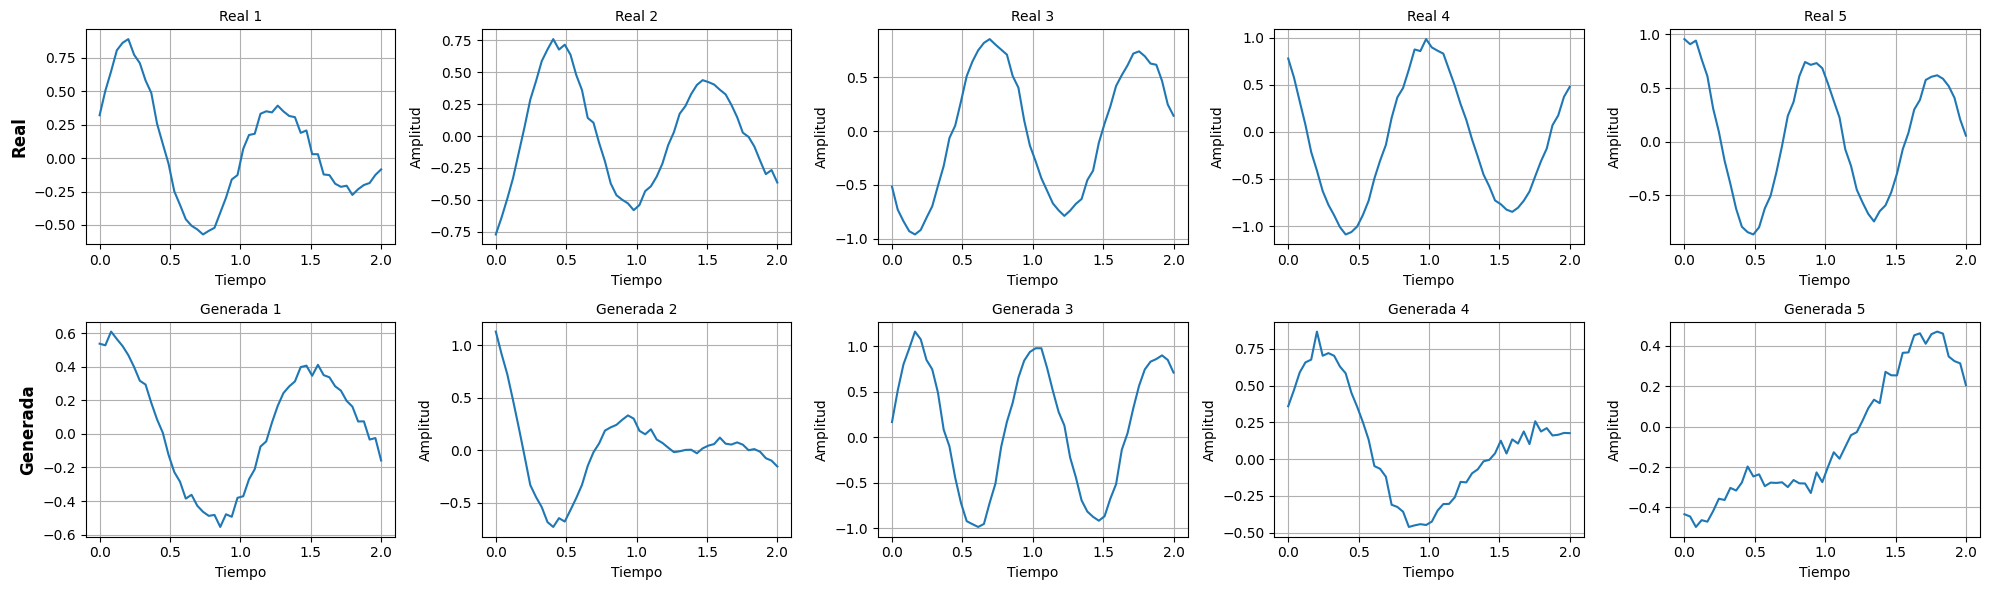

In [30]:
# Muestrear nuevas señales usando el modelo entrenado
generated_signals, snapshots = sample_ddpm(noise_predictor, schedule, n_samples=5, data_dim=signals.shape[1], device=DEVICE)
# Visualizar señales generadas vs reales
def compare_generated_vs_real(generated, real, t):
    n_samples = generated.size(0)
    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 4, 6))
    for i in range(n_samples):
        axes[0, i].plot(t.cpu(), real[i].cpu())
        axes[0, i].set_title(f"Real {i+1}", fontsize=10)
        axes[0, i].set_xlabel("Tiempo")
        axes[0, i].set_ylabel("Amplitud")
        axes[0, i].grid(True)

        axes[1, i].plot(t.cpu(), generated[i].cpu())
        axes[1, i].set_title(f"Generada {i+1}", fontsize=10)
        axes[1, i].set_xlabel("Tiempo")
        axes[1, i].set_ylabel("Amplitud")
        axes[1, i].grid(True)

    axes[0, 0].set_ylabel("Real", fontsize=12, fontweight="bold")
    axes[1, 0].set_ylabel("Generada", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

compare_generated_vs_real(generated_signals, signals[:5], t)